# 08 — Simple Forecasting Baselines

**Student:** Nosirov Nodir  
**Group:** Tulpar

This notebook evaluates two simple one-week-ahead forecasts on the chronological validation period. It does not train a machine-learning model and does not use test targets.

## 1. Evaluation rules

The main baseline is the mean of the previous four complete weeks for the same store-product series. The previous-week value is a second reference. MAE is the primary metric because it is the average absolute error in sold units; RMSE is supporting evidence that gives more weight to large errors.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path("/content/retail-demand-forecasting")]
    for candidate in candidates:
        if (candidate / "data" / "processed" / "m5_foods_features" / "validation.parquet").exists():
            return candidate.resolve()
    raise FileNotFoundError("Validation features were not found. Run notebook 07 first.")

PROJECT_ROOT = find_project_root()
VALIDATION_FILE = PROJECT_ROOT / "data" / "processed" / "m5_foods_features" / "validation.parquet"
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_DIR.mkdir(exist_ok=True)

columns = [
    "week_start", "item_id", "dept_id", "store_id",
    "dataset_split", "weekly_units_sold", "sales_lag_1",
    "sales_roll_mean_4",
]
validation = pd.read_parquet(VALIDATION_FILE, columns=columns)
validation = validation.sort_values(["week_start", "store_id", "item_id"]).reset_index(drop=True)
print("Validation rows:", f"{len(validation):,}")
print("Validation weeks:", validation["week_start"].nunique())
print("Date range:", validation["week_start"].min().date(), "to", validation["week_start"].max().date())

Validation rows: 57,478
Validation weeks: 4
Date range: 2016-03-28 to 2016-04-18


## 2. Create predictions and metrics

Both predictions already come from past-only features created in notebook 07. No value is fitted to validation targets.

In [2]:
target = "weekly_units_sold"
prediction_columns = {
    "previous_4_week_mean": "sales_roll_mean_4",
    "previous_week": "sales_lag_1",
}

def regression_metrics(actual, predicted):
    error = predicted - actual
    return {
        "mae": np.abs(error).mean(),
        "rmse": np.sqrt(np.square(error).mean()),
        "mean_error": error.mean(),
    }

metric_rows = []
for baseline_name, prediction_column in prediction_columns.items():
    metric_rows.append({
        "baseline": baseline_name,
        "rows": len(validation),
        **regression_metrics(validation[target], validation[prediction_column]),
    })

baseline_metrics = pd.DataFrame(metric_rows).sort_values("mae").reset_index(drop=True)
display(baseline_metrics)

,baseline,rows,mae,rmse,mean_error
0,previous_4_week_mean,57478,4.517,10.130,-0.025
1,previous_week,57478,5.031,10.580,0.109


## 3. Review stores and departments

Group results reveal whether an overall average hides weaker performance in part of the dataset. Both baselines are evaluated on every validation row in each group.

In [3]:
def grouped_metrics(data, group_column):
    rows = []
    for group_value, group in data.groupby(group_column, observed=True):
        for baseline_name, prediction_column in prediction_columns.items():
            rows.append({
                group_column: group_value,
                "baseline": baseline_name,
                "rows": len(group),
                **regression_metrics(group[target], group[prediction_column]),
            })
    return pd.DataFrame(rows)

store_metrics = grouped_metrics(validation, "store_id")
department_metrics = grouped_metrics(validation, "dept_id")

display(store_metrics.loc[store_metrics["baseline"].eq("previous_4_week_mean")].sort_values("mae"))
display(department_metrics.loc[department_metrics["baseline"].eq("previous_4_week_mean")].sort_values("mae"))

,store_id,baseline,rows,mae,rmse,mean_error
6,CA_4,previous_4_week_mean,5748,3.163,5.313,-0.016
8,TX_1,previous_4_week_mean,5748,3.503,7.601,-0.117
10,TX_2,previous_4_week_mean,5748,3.944,8.017,0.628
14,WI_1,previous_4_week_mean,5748,3.998,7.145,0.026
12,TX_3,previous_4_week_mean,5748,4.017,8.449,0.209
2,CA_2,previous_4_week_mean,5748,4.455,8.517,-0.607
0,CA_1,previous_4_week_mean,5747,4.741,9.689,-0.038
18,WI_3,previous_4_week_mean,5748,4.783,10.485,-0.181
4,CA_3,previous_4_week_mean,5747,5.798,12.975,0.551
16,WI_2,previous_4_week_mean,5748,6.771,17.571,-0.707


,dept_id,baseline,rows,mae,rmse,mean_error
2,FOODS_2,previous_4_week_mean,15920,3.533,7.562,-0.294
0,FOODS_1,previous_4_week_mean,8640,3.697,6.641,0.666
4,FOODS_3,previous_4_week_mean,32918,5.208,11.830,-0.077


## 4. Verification checks and reports

The checks confirm that only validation rows are evaluated, all predictions are present and non-negative, group row accounting is complete, and test data was not loaded.

In [4]:
primary_name = "previous_4_week_mean"
primary_store_rows = int(store_metrics.loc[store_metrics["baseline"].eq(primary_name), "rows"].sum())
primary_department_rows = int(department_metrics.loc[department_metrics["baseline"].eq(primary_name), "rows"].sum())

checks = pd.DataFrame([
    {"check": "validation split only", "status": "PASS" if validation["dataset_split"].eq("validation").all() else "FAIL", "details": str(validation["dataset_split"].unique().tolist())},
    {"check": "four chronological validation weeks", "status": "PASS" if validation["week_start"].nunique() == 4 else "FAIL", "details": str(validation["week_start"].nunique())},
    {"check": "prediction values present", "status": "PASS" if validation[list(prediction_columns.values())].notna().all().all() else "FAIL", "details": str(int(validation[list(prediction_columns.values())].isna().sum().sum()))},
    {"check": "prediction values non-negative", "status": "PASS" if validation[list(prediction_columns.values())].ge(0).all().all() else "FAIL", "details": "sales cannot be negative"},
    {"check": "store row accounting", "status": "PASS" if primary_store_rows == len(validation) else "FAIL", "details": str(primary_store_rows)},
    {"check": "department row accounting", "status": "PASS" if primary_department_rows == len(validation) else "FAIL", "details": str(primary_department_rows)},
    {"check": "test file not loaded", "status": "PASS", "details": VALIDATION_FILE.name},
])

assert checks["status"].eq("PASS").all()
assert np.isfinite(baseline_metrics[["mae", "rmse", "mean_error"]].to_numpy()).all()

baseline_metrics.to_csv(REPORT_DIR / "baseline_metrics_validation.csv", index=False)
store_metrics.to_csv(REPORT_DIR / "baseline_store_metrics_validation.csv", index=False)
department_metrics.to_csv(REPORT_DIR / "baseline_department_metrics_validation.csv", index=False)
checks.to_csv(REPORT_DIR / "baseline_checks.csv", index=False)
display(checks)

,check,status,details
0,validation split only,PASS,['validation']
1,four chronological validation weeks,PASS,4
2,prediction values present,PASS,0
3,prediction values non-negative,PASS,sales cannot be negative
4,store row accounting,PASS,57478
5,department row accounting,PASS,57478
6,test file not loaded,PASS,validation.parquet


## 5. Visual comparison

The metric chart compares individual store-product predictions. The weekly chart aggregates actual and predicted units only for an easy visual check; metrics above remain row-level.

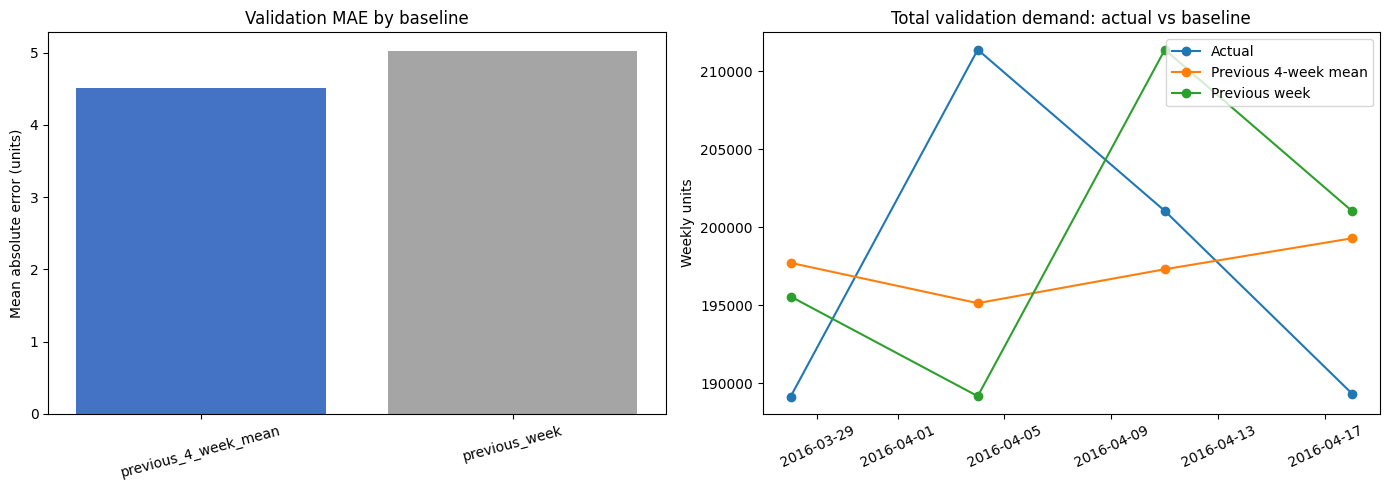

In [5]:
weekly = validation.groupby("week_start", as_index=False, observed=True).agg(
    actual_units=(target, "sum"),
    previous_4_week_mean=("sales_roll_mean_4", "sum"),
    previous_week=("sales_lag_1", "sum"),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(baseline_metrics["baseline"], baseline_metrics["mae"], color=["#4472C4", "#A5A5A5"])
axes[0].set_title("Validation MAE by baseline")
axes[0].set_ylabel("Mean absolute error (units)")
axes[0].tick_params(axis="x", rotation=15)

axes[1].plot(weekly["week_start"], weekly["actual_units"], marker="o", label="Actual")
axes[1].plot(weekly["week_start"], weekly["previous_4_week_mean"], marker="o", label="Previous 4-week mean")
axes[1].plot(weekly["week_start"], weekly["previous_week"], marker="o", label="Previous week")
axes[1].set_title("Total validation demand: actual vs baseline")
axes[1].set_ylabel("Weekly units")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

## 6. Result

The better validation baseline becomes the minimum reference that trained models should improve upon. The test period remains untouched until final model selection.